Usamos librería math para hacer cálculos intermedios de manera más automática y librería random para la inicialización de valores aleatorios como por ejemplo para el ejercicio 7.a 

### Ejercicio 1: Funciones Base de Bernstein

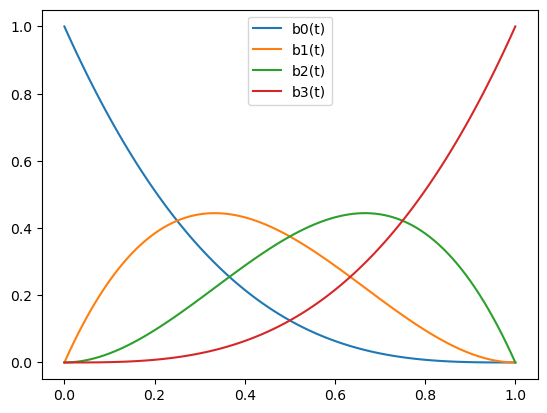

False


In [480]:
# Inciso (a)

import math
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(42)

def bernstein3(t):
    matriz = np.zeros((len(t), 4))
    for i in range(len(t)):
        x = t[i]
        b0 = (1-x)**3
        b1 = 3*((1-x)**2)*x
        b2 = 3*(1-x)*(x**2)
        b3 = x**3
        matriz[i][0] = b0
        matriz[i][1] = b1
        matriz[i][2] = b2
        matriz[i][3] = b3

    return matriz

# Inciso (b)

def graficar():
    
    t = np.array([])
    for x in range(101):
        t = np.append(t, x / 100)

    matriz = bernstein3(t)

    ys0 = []
    ys1 = []
    ys2 = []
    ys3 = []

    for i in range(len(matriz)):
        ys0.append(matriz[i][0])
        ys1.append(matriz[i][1])
        ys2.append(matriz[i][2])
        ys3.append(matriz[i][3])



    plt.plot(t, ys0, label = "b0(t)")
    plt.plot(t, ys1,label = "b1(t)")
    plt.plot(t, ys2,label = "b2(t)")
    plt.plot(t, ys3,label = "b3(t)")
    plt.legend()

    plt.show()    


graficar()

# Inciso (c)

def verificacion(matriz):
    
    cumple = True
    for i in range(len(matriz[0])):
        suma = matriz[0][i] + matriz[1][i] + matriz[2][i] + matriz[3][i]
        cumple = np.isclose(suma, 1)
    return cumple

t = np.array([])
for x in range(101):
    t = np.append(t, x / 100)
print(verificacion(bernstein3(t)))


Inciso (d)

Como los coeficientes de la curva de Bezier suman 1, cada punto de control de la curva tiene un "peso" asignadoque funciona como un promedio ponderado entre los puntos. Cada caoeficiente indica cuanto influye cada punto de control en la posición de la curva. Es por esto que la curva queda contenida entre los puntos de control. 

### Ejercicio 2

[[1.00000e+00 0.00000e+00 0.00000e+00 0.00000e+00]
 [9.70299e-01 2.94030e-02 2.97000e-04 1.00000e-06]
 [9.41192e-01 5.76240e-02 1.17600e-03 8.00000e-06]
 [9.12673e-01 8.46810e-02 2.61900e-03 2.70000e-05]
 [8.84736e-01 1.10592e-01 4.60800e-03 6.40000e-05]
 [8.57375e-01 1.35375e-01 7.12500e-03 1.25000e-04]
 [8.30584e-01 1.59048e-01 1.01520e-02 2.16000e-04]
 [8.04357e-01 1.81629e-01 1.36710e-02 3.43000e-04]
 [7.78688e-01 2.03136e-01 1.76640e-02 5.12000e-04]
 [7.53571e-01 2.23587e-01 2.21130e-02 7.29000e-04]
 [7.29000e-01 2.43000e-01 2.70000e-02 1.00000e-03]
 [7.04969e-01 2.61393e-01 3.23070e-02 1.33100e-03]
 [6.81472e-01 2.78784e-01 3.80160e-02 1.72800e-03]
 [6.58503e-01 2.95191e-01 4.41090e-02 2.19700e-03]
 [6.36056e-01 3.10632e-01 5.05680e-02 2.74400e-03]
 [6.14125e-01 3.25125e-01 5.73750e-02 3.37500e-03]
 [5.92704e-01 3.38688e-01 6.45120e-02 4.09600e-03]
 [5.71787e-01 3.51339e-01 7.19610e-02 4.91300e-03]
 [5.51368e-01 3.63096e-01 7.97040e-02 5.83200e-03]
 [5.31441e-01 3.73977e-01 8.772

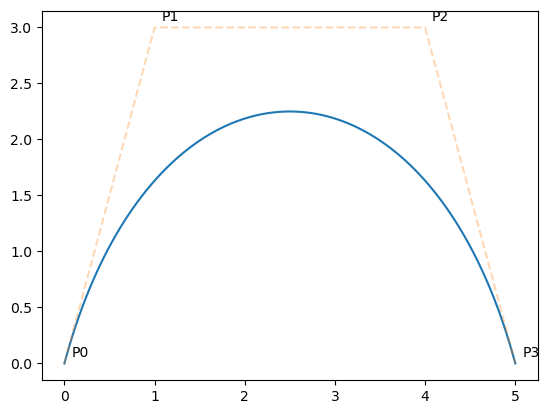

In [481]:


# Inciso (a)

t = []
for x in range(101):
    t.append(x / 100)

matriz_A = bernstein3(t)

print(matriz_A)

# Inciso (b)

def P(P1,P2,P3,P4):

    filas_puntos = []
    filas_puntos.append(P1)
    filas_puntos.append(P2)
    filas_puntos.append(P3)
    filas_puntos.append(P4)
    matriz_P = np.array(filas_puntos)
    return matriz_P

matriz_P = P([0,0],[1,3],[4,3],[5,0])
print(matriz_P)

# Inciso (c)

def curva(matriz_A, matriz_P):
    matriz_C = matriz_A @ matriz_P

    return matriz_C

matriz_C = curva(matriz_A, matriz_P)
print(matriz_C)

# Inciso (d)

# Recibe una matriz de los puntos obtenidos de una curva y una matriz de los puntos de control. Con la primera grafica la curva, con la segunda el poligono de control.
def graficar_matriz(matriz_curva, puntos_control, nombre=None):

    xs = []
    ys = []
    for punto in matriz_curva:
        xs.append(punto[0])
        ys.append(punto[1])
        
    plt.plot(xs,ys, label = nombre)

    poligonal_control_x = []
    poligonal_control_y = []
    for punto in puntos_control:
        poligonal_control_x.append(punto[0])
        poligonal_control_y.append(punto[1])

    # Poligonal de control
    plt.plot(poligonal_control_x, poligonal_control_y, '--', alpha=0.3)

    # Puntos de control (etiquetas)
    for i, (x, y) in enumerate(puntos_control): 
        plt.annotate(f"P{i}", (x, y), textcoords="offset points", xytext=(5, 5))

    #plt.show()
    

graficar_matriz(matriz_C, matriz_P, "Curva de Bezier")

Inciso (e)

Matriz A: dimension 100x4

Esta matriz representa los coeficientes del polinomio de Bernstein evaluados en 100 valores de t entre 0 y 1 (equiespaciados). Cada columna representa un coeficiente de Bernstein (b0, b1, b2 y b3) y cada fila es una evaluacion de los cuatro coeficientes para cierto valor t. 

Matriz P: dimension 4x2

Esta matriz representa los 4 puntos de control (uno por fila) de la curva de Bezier. Cada fila contiene 2 coordenadas para dicho punto. 

Matriz C: dimension 100x2

Esta matriz representa 100 puntos de la curva de Bezier (uno pr fila, donde cada fila contiene 2 coordenadas para dicho punto). 

### Ejercicio 3

[[0.         0.        ]
 [0.11041863 0.29964328]
 [0.23412194 0.57788347]
 [0.37012588 0.83472057]
 [0.51744639 1.07015458]
 [0.67509943 1.28418549]
 [0.84210095 1.47681332]
 [1.01746689 1.64803805]
 [1.20021321 1.79785969]
 [1.38935586 1.92627824]
 [1.58391078 2.0332937 ]
 [1.78289393 2.11890606]
 [1.98532125 2.18311534]
 [2.1902087  2.22592152]
 [2.39657223 2.24732461]
 [2.60342777 2.24732461]
 [2.8097913  2.22592152]
 [3.01467875 2.18311534]
 [3.21710607 2.11890606]
 [3.41608922 2.0332937 ]
 [3.61064414 1.92627824]
 [3.79978679 1.79785969]
 [3.98253311 1.64803805]
 [4.15789905 1.47681332]
 [4.32490057 1.28418549]
 [4.48255361 1.07015458]
 [4.62987412 0.83472057]
 [4.76587806 0.57788347]
 [4.88958137 0.29964328]
 [5.         0.        ]]
[[ 4.96714153e-03 -1.38264301e-03]
 [ 1.16895517e-01  3.14873580e-01]
 [ 2.31780406e-01  5.75542102e-01]
 [ 3.85918005e-01  8.42394918e-01]
 [ 5.12751646e-01  1.07558018e+00]
 [ 6.70465253e-01  1.27952820e+00]
 [ 8.44520570e-01  1.45768052e+00]
 [ 1

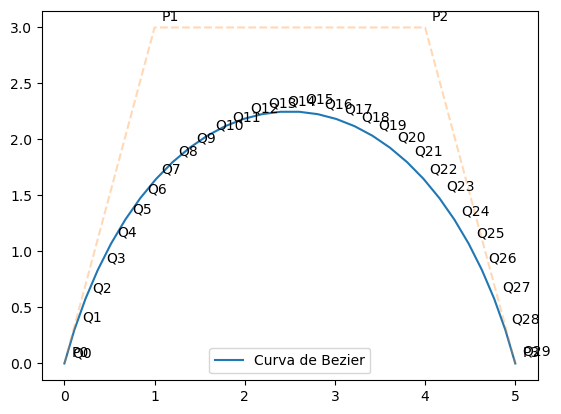

In [482]:

# Inciso (a)

t = []
for x in range(30):
    t.append(x / 29)


# Inciso (b)

matriz_A2 = bernstein3(t)

matriz_P2 = P([0,0], [1,3], [4,3], [5,0])
matriz_C2 = curva(matriz_A2, matriz_P2)

print(matriz_C2)

# Inciso (c)

# Toma una matriz de la curva (puntos observados) y les agrega ruido segun un sigma (controla la desviacion estandar)
def ruido_gaussiano(matriz_C, sigma):
    vector_ruidos = []
    matriz_ruido = matriz_C.copy()
    for i in range(len(matriz_C)):
        ruido_x = np.random.normal(0, sigma)
        ruido_y = np.random.normal(0, sigma)
        vector_ruidos.append([ruido_x,ruido_y])
        matriz_ruido[i] = [matriz_C[i][0]+ruido_x, matriz_C[i][1]+ ruido_y] 
    return matriz_ruido

matriz_ruido = ruido_gaussiano(matriz_C2, 0.01)
print(matriz_ruido)

# Inciso (d)

graficar_matriz(matriz_C2, matriz_P, "Curva de Bezier")

for i, (x, y) in enumerate(matriz_ruido): 
        plt.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5))
plt.legend()
plt.show()



### Ejercicio 4

In [483]:
#inciso a)

A = bernstein3(t)

#inciso b)

matriz_Q = matriz_ruido.copy()




inciso b) Buscamos la matriz $\hat P \in \mathbb{R}^{4\times 2}$ que minimice el error cuadrático

$$
\hat P = \arg\min_{P \in \mathbb{R}^{4\times 2}}
\|AP-Q\|_F^2.
$$

Sea

$$
Q =
\begin{bmatrix}
q_1 & q_2
\end{bmatrix},
\qquad
P =
\begin{bmatrix}
p_1 & p_2
\end{bmatrix},
$$

donde $q_1,q_2 \in \mathbb{R}^{m}$ y $p_1,p_2 \in \mathbb{R}^{4}$.

Entonces

$$
AP-Q
=
\begin{bmatrix}
Ap_1-q_1 & Ap_2-q_2
\end{bmatrix}.
$$

Como la norma de Frobenius al cuadrado es la suma de los cuadrados de todas las entradas,

$$
\|AP-Q\|_F^2
=
\|Ap_1-q_1\|^2
+
\|Ap_2-q_2\|^2.
$$

Por lo tanto, el problema se descompone en dos problemas independientes de mínimos cuadrados:

$$
\min_{p_1}\|Ap_1-q_1\|^2,
\qquad
\min_{p_2}\|Ap_2-q_2\|^2.
$$

Para cada columna, la condición de optimalidad viene dada por las ecuaciones normales

$$
A^T(Ap_i-q_i)=0,
$$

es decir,

$$
A^TAp_i=A^Tq_i,
\qquad i=1,2.
$$

Agrupando ambas ecuaciones en forma matricial obtenemos

$$
A^TAP=A^TQ.
$$

Si $A^TA$ es invertible, la solución es

$$
\hat P=(A^TA)^{-1}A^TQ.
$$

[[6.37720785e-03 4.95044917e-03]
 [9.85364575e-01 2.98971294e+00]
 [4.00232683e+00 2.99283736e+00]
 [4.99953692e+00 4.94987417e-03]]


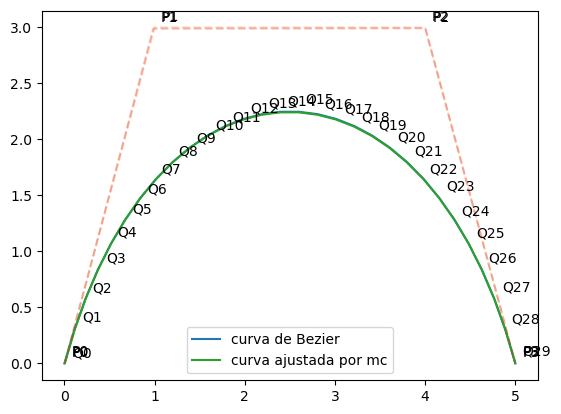

In [484]:
#inciso (c)
def ec_normal(A, matriz_Q):
    A_traspuesta = A.T
    matriz_producto = A_traspuesta @ A

    inversa = np.linalg.inv(matriz_producto)

    matriz_P_sombrero = (inversa @ A_traspuesta) 
    matriz_P_sombrero = matriz_P_sombrero @ matriz_Q

    #print(np.linalg.det(A.T @ A)) #Te dice el valor del determinante

    return matriz_P_sombrero


matriz_puntos_ajustados = ec_normal(A, matriz_Q)
matriz_curva_ajustada = A @ matriz_puntos_ajustados

print(ec_normal(A, matriz_Q))

#inciso (d)
graficar_matriz(matriz_C2, matriz_P, "curva de Bezier")
graficar_matriz(matriz_curva_ajustada, matriz_puntos_ajustados, "curva ajustada por mc")

for i, (x, y) in enumerate(matriz_ruido): 
        plt.annotate(f"Q{i}", (x, y), textcoords="offset points", xytext=(5, 5))
plt.legend()
plt.show()

Inciso (e)

No, los puntos de control estimados no son exactamente iguales a los originales porque trabajamos con puntos de la curva a los que les agregamos ruido. Al hacer el ajuste, el algoritmo intenta encontrar los puntos de control que mejor reproduzcan esos datos modificados, por lo que obtiene valores parecidos a los originales, pero no exactamente iguales.

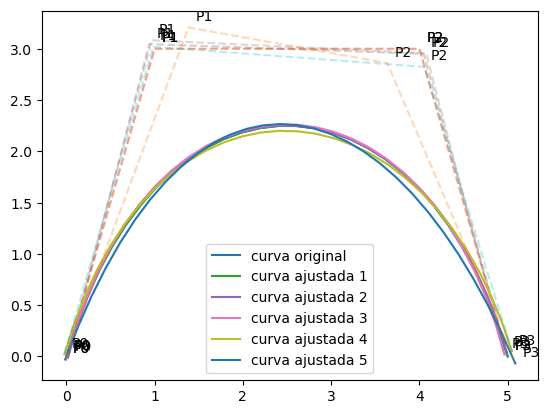

In [485]:

# Inciso (f)

sigmas = [0.00, 0.02, 0.05, 0.10, 0.20]

matriz_ruido_1 = ruido_gaussiano(matriz_C2, sigmas[0])
matriz_ruido_2 = ruido_gaussiano(matriz_C2, sigmas[1])
matriz_ruido_3 = ruido_gaussiano(matriz_C2, sigmas[2])
matriz_ruido_4 = ruido_gaussiano(matriz_C2, sigmas[3])
matriz_ruido_5 = ruido_gaussiano(matriz_C2, sigmas[4])

# Inciso (g)

matriz_pc_ajustados1 = ec_normal(A, matriz_ruido_1)
matriz_pc_ajustados2 = ec_normal(A, matriz_ruido_2)
matriz_pc_ajustados3 = ec_normal(A, matriz_ruido_3)
matriz_pc_ajustados4 = ec_normal(A, matriz_ruido_4)
matriz_pc_ajustados5 = ec_normal(A, matriz_ruido_5)

matriz_curva_ajustada1 = A @ matriz_pc_ajustados1
matriz_curva_ajustada2 = A @ matriz_pc_ajustados2
matriz_curva_ajustada3 = A @ matriz_pc_ajustados3
matriz_curva_ajustada4 = A @ matriz_pc_ajustados4
matriz_curva_ajustada5 = A @ matriz_pc_ajustados5

graficar_matriz(matriz_C2, matriz_P, "curva original")
graficar_matriz(matriz_curva_ajustada1, matriz_pc_ajustados1, "curva ajustada 1")
graficar_matriz(matriz_curva_ajustada2, matriz_pc_ajustados2, "curva ajustada 2")
graficar_matriz(matriz_curva_ajustada3, matriz_pc_ajustados3, "curva ajustada 3")
graficar_matriz(matriz_curva_ajustada4, matriz_pc_ajustados4, "curva ajustada 4")
graficar_matriz(matriz_curva_ajustada5, matriz_pc_ajustados5, "curva ajustada 5")

plt.legend()
plt.show()






In [486]:
# Inciso (h)

errores = []
curvas_ajustadas = [matriz_curva_ajustada1,matriz_curva_ajustada2, matriz_curva_ajustada3, matriz_curva_ajustada4, matriz_curva_ajustada5]

for i in range(len(curvas_ajustadas)):
    resta = matriz_C2 - curvas_ajustadas[i]
    matriz_al_cuadrado = resta**2
    
    ECM = (np.sum(matriz_al_cuadrado))*(1/len(matriz_C2))
    errores.append(ECM)
    print("Sigma = ", sigmas[i], "    ", "ECM: ", ECM)


Sigma =  0.0      ECM:  3.892901993345551e-30
Sigma =  0.02      ECM:  0.0001870043969738478
Sigma =  0.05      ECM:  0.0003236696913667062
Sigma =  0.1      ECM:  0.0022156205772125167
Sigma =  0.2      ECM:  0.006468979945727048


Se observa que el ECM aumenta al aumentar σ. Esto era esperable, ya que un mayor nivel de ruido implica una mayor desviación respecto de los datos originales, lo que empeora la calidad del ajuste.


- La curva ajustada suele seguir recuperando la forma general de la curva original, especialmente para valores moderados de σ.
- Sin embargo, el ajuste es menos preciso y pueden aparecer pequeñas deformaciones respecto de la curva original.
- Los puntos de control estimados se alejan más de los puntos de control originales, es decir, la estimación de esos puntos es menos exacta.



### Ejercicio 5

$$
\begin{aligned}
E(p)
&= \|Ap-q\|^2 \\
&= (Ap-q) \cdot (Ap-q) \\
\end{aligned}

$$
Como Ap-q es un vector, lo podemos trasponer para el producto vectorial consigo mismo 
$$

\begin{aligned}
&= (Ap-q)^T(Ap-q) \\
&= (Ap)^T(Ap) - (Ap)^Tq - q^T(Ap) + q^Tq \\
&= p^TA^TAp - p^TA^Tq - q^TAp + q^Tq.
\end{aligned}
$$

Además, como $$ (p^TA^Tq) $$ es un escalar, podemos trasponerlo

$$
p^TA^Tq = (p^TA^Tq)^T = q^TAp.
$$

Por lo tanto,

$$
\begin{aligned}
E(p)
&= p^TA^TAp - q^TAp - q^TAp + q^Tq \\
&= p^TA^TAp - 2q^TAp + q^Tq.
\end{aligned}
$$

En conclusión,

$$
E(p)=p^TA^TAp-2q^TAp+q^Tq.
$$

Inciso (b)

\begin{aligned}
E(p) 
&= \|Ap-q\|^2 \\
&= (Ap-q)^2 \\
&= (Ap)^2 - 2Apq + q^2  \\

\end{aligned}


Las partes cuadráticas son el primer término (tienen las variable p dos veces, grado 2 de la variable p en $E(p)$ ).

Cuando hablamos de "parte cuadrática" nos referimos a los términos que tienen a la variable p multiplicándose consigo misma.
$$
E(p)=p^TA^TAp-2q^TAp+q^Tq.
$$

La expresión está compuesta por tres tipos de términos:

- $p^T A^T A p$: término cuadrático en $p$.
- $-2q^T A p$: término lineal en $p$.
- $q^T q$: término constante.


Por lo tanto, la parte cuadrática de $E(p)$ es

$$
p^TA^TAp.
$$

In [487]:
# Inciso (c)

simetria1 = (A.T @ (A)).T
simetria2 = (A.T) @ (A)

if(np.allclose(simetria1, simetria2)):
    print("Son simetricas")

Son simetricas


In [488]:
# Inciso (d)

autovalores, autovectores = np.linalg.eig(A.T @ A)
print("Autovalores de A^T * A: ", autovalores, "\n")
print("Autovectores de A^T * A: \n", autovectores)

Autovalores de A^T * A:  [7.51154315 4.8161144  1.70568592 0.25824389] 

Autovectores de A^T * A: 
 [[ 0.52179727  0.67835134  0.47720814 -0.19959826]
 [ 0.47720814  0.19959826 -0.52179727  0.67835134]
 [ 0.47720814 -0.19959826 -0.52179727 -0.67835134]
 [ 0.52179727 -0.67835134  0.47720814  0.19959826]]


Inciso (e)

Todos los autovalores de $$ A^T * A\ $$ son positivos. Esto indica que la parte cuadrática de la función de error es definida positiva, por lo que E(p) es una función convexa con forma de cuenco y posee un único mínimo global.

### Ejercicio 6

In [489]:
# Inciso (a)

def gradiente(p, A, q):
    res = 2*((A.T)@((A@p)-q))

    return res

# Inciso (b)
p = np.array([0,0,0,0]).reshape(4,1)
q = matriz_ruido[:,0].reshape(30,1)
print(gradiente(p, A, q))

# Inciso (c)

matriz_p_sombrero = matriz_puntos_ajustados.copy()[:,0].reshape(4,1)
gradiente_p_sombrero = gradiente(matriz_p_sombrero,A,q)
print(gradiente_p_sombrero)

# Inciso (d)

ceros = np.zeros((4,1))
if(np.allclose(gradiente_p_sombrero, ceros)):
    print("El gradiente de la matriz_p_sombrero es aproximadamente cero")



[[-12.82833063]
 [-28.13287195]
 [-44.20803653]
 [-64.74426935]]
[[ 2.78256077e-15]
 [ 1.33342908e-14]
 [ 1.46447360e-14]
 [-6.13658430e-15]]
El gradiente de la matriz_p_sombrero es aproximadamente cero


Inciso (e)

$$ \nabla E(p) = 2 A^T (Ap - q)$$

Si pedimos que $$ \nabla E(p) = 0 $$ 


$$
2A^T(Ap-q)=0
$$

$$
A^T(Ap-q)=0
$$

$$
A^TAp - A^Tq = 0
$$

$$
A^TAp=A^Tq
$$

### Ejercicio 7

[[0.74604488]
 [0.58336877]
 [0.96217255]
 [0.37487058]]
(array([[0.74604488, 0.58336877, 0.96217255, 0.37487058],
       [0.76323023, 0.76282925, 1.30683927, 0.93492093]]), array([184.86769629, 141.43087185]))
-------------
Valores de pt: 
[[ 0.74604488  0.58336877  0.96217255  0.37487058]
 [ 0.91789835  2.37797361  4.40883978  5.97537413]
 [-0.61398825  0.99630981  3.13385357  4.62962628]
 ...
 [ 0.00637721  0.98536458  4.00232683  4.99953692]
 [ 0.00637721  0.98536458  4.00232683  4.99953692]
 [ 0.00637721  0.98536458  4.00232683  4.99953692]]
-------------
Valores de error para los valores de pt: 
[1.84867696e+02 2.57618173e+01 6.55119940e+00 ... 1.84854519e-03
 1.84854519e-03 1.84854519e-03]


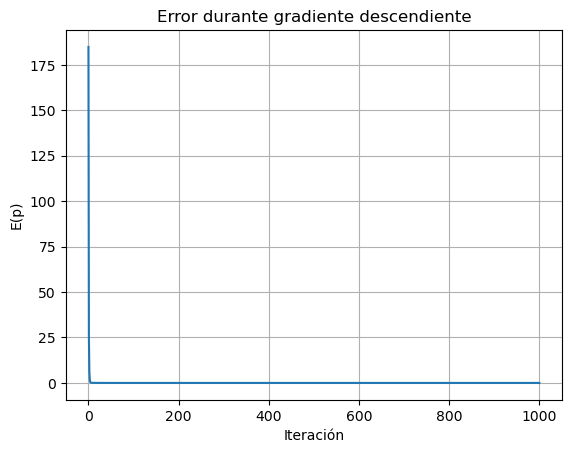

0.0018485451935816855
[[0.00184855]]
Con gradiente descendiente llegamos a la misma solucion que ecuaciones normales


In [490]:
# Inciso (a)

p0 = np.random.rand(4,1)
print(p0)

# Inciso (b)

def Error_pt(p, A, q):
    return (p.T @ A.T @ (A@p) - 2 * q.T @ A @ p + q.T @ q)

def actualizacion_gd(p0, gradiente_p0, alpha, it):
    E_pt = np.array(Error_pt(p0, A, q))
    pt = [p0.copy()]
    for i in range(it):
        p1 = p0 - (alpha*gradiente_p0)
        pt.append(p1.copy())
        E_pt = np.append(E_pt, Error_pt(p1, A, q))
        p0 = p1
        gradiente_p0 = gradiente(p0, A, q)
    pt = np.array(pt).reshape(len(pt), 4)
    
    return pt, E_pt

gradiente_p0 = gradiente(p0, A, q)
print(actualizacion_gd(p0, gradiente_p0, 0.01, 1))


# Inciso (c)
pt, E_pt = actualizacion_gd(p0, gradiente_p0, 0.1, 1000)
print("-------------")
print("Valores de pt: ")
print(pt)
print("-------------")
print("Valores de error para los valores de pt: ")
print(E_pt)

# Inciso (d)

plt.plot(E_pt)
plt.xlabel("Iteración")
plt.ylabel("E(p)")
plt.title("Error durante gradiente descendiente")
plt.grid(True)

plt.show()

# Inciso (e)

p_final = pt[1000].reshape(4,1)

print(E_pt[1000])
print(Error_pt(matriz_p_sombrero, A, q))

if(np.allclose(matriz_p_sombrero, p_final)):
    print("Con gradiente descendiente llegamos a la misma solucion que ecuaciones normales")






### Ejercicio 8

In [491]:
# Inciso (a)

alphas = [0.001, 0.01, 0.05, 0.1, 0.2]

nuevo_p0 = np.random.rand(4,1)
nuevo_gradiente_p0 = gradiente(nuevo_p0, A, q)

pt1, E_pt1 = actualizacion_gd(nuevo_p0.copy(), nuevo_gradiente_p0.copy(), alphas[0], 1000)
pt2, E_pt2 = actualizacion_gd(nuevo_p0.copy(), nuevo_gradiente_p0.copy(), alphas[1], 1000)
pt3, E_pt3 = actualizacion_gd(nuevo_p0.copy(), nuevo_gradiente_p0.copy(), alphas[2], 1000)
pt4, E_pt4= actualizacion_gd(nuevo_p0.copy(), nuevo_gradiente_p0.copy(), alphas[3], 1000)
pt5, E_pt5= actualizacion_gd(nuevo_p0.copy(), nuevo_gradiente_p0.copy(), alphas[4], 1000)


print("\n Errores para alpha = 0.001: ")
print(E_pt1)
print("-------------")

print("Errores para alpha = 0.01: ")
print(E_pt2)
print("-------------")

print("Errores para alpha = 0.05: ")
print(E_pt3)
print("-------------")

print("Errores para alpha = 0.1: ")
print(E_pt4)
print("-------------")

print("Errores para alpha = 0.2: ")
print(E_pt5)
print("-------------")




        


 Errores para alpha = 0.001: 
[174.81379659 170.30907527 165.92549145 ...   0.24443484   0.24418369
   0.24393281]
-------------
Errores para alpha = 0.01: 
[1.74813797e+02 1.32530661e+02 1.00877148e+02 ... 1.87061115e-03
 1.87038380e-03 1.87015879e-03]
-------------
Errores para alpha = 0.05: 
[1.74813797e+02 2.48220615e+01 5.73579334e+00 ... 1.84854519e-03
 1.84854519e-03 1.84854519e-03]
-------------
Errores para alpha = 0.1: 
[1.74813797e+02 2.83901855e+01 7.54620249e+00 ... 1.84854519e-03
 1.84854519e-03 1.84854519e-03]
-------------
Errores para alpha = 0.2: 
[ 174.81379659  496.2060104  1817.3560036  ...           inf           inf
           inf]
-------------


/var/folders/xd/k_n5rxfn4r7056q679b_6j8m0000gn/T/ipykernel_96251/3829890200.py:9: RuntimeWarning: overflow encountered in matmul
  return (p.T @ A.T @ (A@p) - 2 * q.T @ A @ p + q.T @ q)


- $\alpha = 0.001:$ converge, pero muy lentamente. Después de 1000 iteraciones todavía queda en 0.122.
- $\alpha = 0.01:$ converge mejor, baja hasta cerca del mínimo.
- $\alpha = 0.05$ y $\alpha = 0.1:$ convergen rápido y llegan al mínimo 0.001848....
- $\alpha = 0.2:$ diverge. El error crece muchísimo hasta inf.


Para valores chicos de $\alpha$, el método converge pero lentamente (puede no llegar al valor mínimo). Para valores intermedios, converge más rápido al mismo valor mínimo. En cambio, para $\alpha$ = 0.2, el método diverge: el error crece hasta infinito numérico, lo que muestra que una tasa de aprendizaje demasiado grande vuelve inestable la actualización.




/Users/franchu/anaconda3/lib/python3.11/site-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, a)


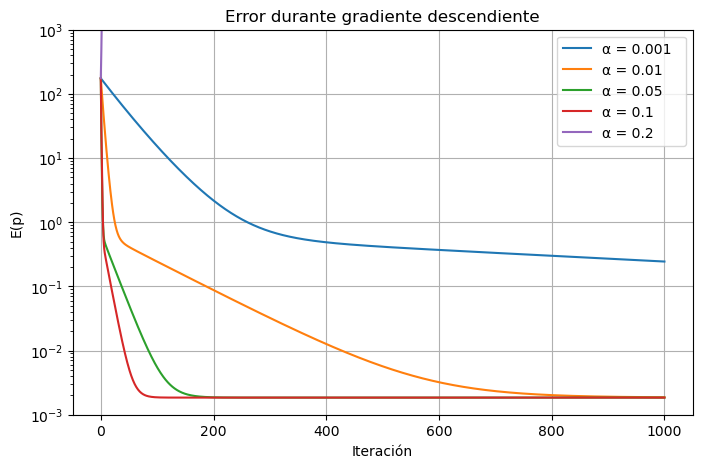

In [492]:
# Inciso (b)

def graficar_error(errores, alpha, extra_label=" "):
    plt.plot(errores, label=f"α = {alpha} {extra_label}")
    # plt.show()
plt.figure(figsize=(8,5))

graficar_error(E_pt1, alphas[0])
graficar_error(E_pt2, alphas[1])
graficar_error(E_pt3, alphas[2])
graficar_error(E_pt4, alphas[3])
graficar_error(E_pt5, alphas[4])


plt.xlabel("Iteración")
plt.ylabel("E(p)")
plt.yscale("log")
plt.ylim(1e-3, 1e3)
plt.title("Error durante gradiente descendiente")
plt.grid(True)
plt.legend()

plt.show()


Inciso (c)

Un caso en el que el método converge lentamente es en el de $\alpha = 0.001$

Inciso (d)

Un caso en el que el método diverge es en el de $\alpha = 0.2$

Inciso (e)

En el método $\alpha$ representa la tasa de aprendizaje, es decir, el tamaño del paso que da gradiente descendiente en cada iteracion. Es por esto que marca la rapidez con la que el método converge a la solución mínima buscada. 


### Ejercicio 9

In [493]:
# Inciso (a)

def actualizacion_newton(p0, gradiente_p0, hessiano_inv, it):
    pt = [p0.copy()]
    E_pt = np.array(Error_pt(p0, A, q))
    for i in range(it):
        p1 = p0 - hessiano_inv @ gradiente_p0
        pt.append(p1)
        E_pt = np.append(E_pt, Error_pt(p1, A, q))
        p0 = p1
        gradiente_p0 = gradiente(p0, A, q)
    pt = np.array(pt).reshape(len(pt), 4)
    return pt, E_pt

# Inciso (b)

p0_aleatorio = np.random.rand(4,1)
hessiano = 2 * A.T @ A
hessiano_inv = np.linalg.inv(hessiano)

pt1, E_pt1 = actualizacion_newton(p0_aleatorio, gradiente(p0_aleatorio, A, q), hessiano_inv, 1)

print(E_pt)

# Inciso (c)

print(pt1)
p1 = pt1[1].reshape(4,1)
if(np.allclose(p1, matriz_p_sombrero)):
    print("\nEl método de Newton llegó a la misma solucion que mínimos cuadrados")
        
        



[1.84867696e+02 2.57618173e+01 6.55119940e+00 ... 1.84854519e-03
 1.84854519e-03 1.84854519e-03]
[[0.01215447 0.96987883 0.04315991 0.89114311]
 [0.00637721 0.98536458 4.00232683 4.99953692]]

El método de Newton llegó a la misma solucion que mínimos cuadrados


Inciso (d)

El método de Newton utiliza el gradiente y el Hessiano para construir una aproximación de Taylor de segundo orden de la función alrededor del punto actual. En cada iteración se mueve al mínimo de dicha aproximación. En el caso de una función cuadrática, la expansión de Taylor de segundo orden coincide exactamente con la función original, ya que no existen términos de orden superior. Por lo tanto, el mínimo de la aproximación es también el mínimo de la función, y el método llega a la solución exacta en una sola iteración.

Es más, puede verse en el proceso donde $p_t = p_0$ y $p_{t+1} = p_1 = \hat{p}$  



$$
p_{t+1} = p_t - H^{-1}\nabla E(p_t)
$$

Sabemos que:

$$
\nabla E(p_t) = 2A^T(Ap_t-q)
$$

y que:

$$
H = 2A^TA
$$

Entonces:

$$
p_{t+1}
=
p_t - (2A^TA)^{-1} \, 2A^T(Ap_t-q)
$$

Como:

$$
(2A^TA)^{-1} = \frac{1}{2}(A^TA)^{-1}
$$

queda:

$$
p_{t+1}
=
p_t - \frac{1}{2}(A^TA)^{-1} \, 2A^T(Ap_t-q)
$$

Se cancela el $2$:

$$
p_{t+1}
=
p_t - (A^TA)^{-1}A^T(Ap_t-q)
$$

Distribuimos:

$$
p_{t+1}
=
p_t - (A^TA)^{-1}A^TAp_t + (A^TA)^{-1}A^Tq
$$

Como:

$$
(A^TA)^{-1}A^TA = I
$$

entonces:

$$
p_{t+1}
=
p_t - Ip_t + (A^TA)^{-1}A^Tq
$$

$$
p_{t+1}
=
p_t - p_t + (A^TA)^{-1}A^Tq
$$

Finalmente:

$$
p_{t+1}
=
(A^TA)^{-1}A^Tq
=
\hat p
$$

$p_{t+1} = \hat p$ porque es igual a la ecuacion normal que llega finalmente a la solucion de minimos cuadrados.  

[[0.01215447]
 [0.96987883]
 [0.04315991]
 [0.89114311]]
[[6.37720785e-03 4.95044917e-03]
 [9.85364575e-01 2.98971294e+00]
 [4.00232683e+00 2.99283736e+00]
 [4.99953692e+00 4.94987417e-03]]


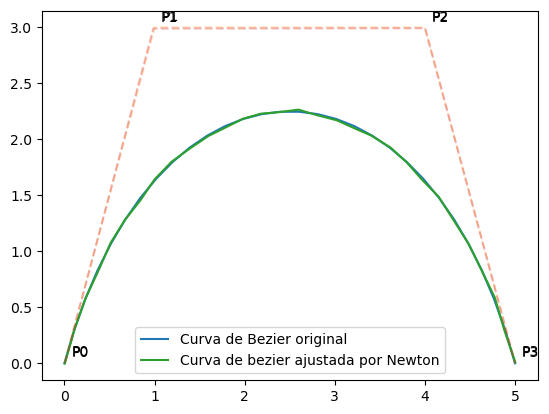

In [494]:
# Inciso (e)
print(p0_aleatorio)

q_x = matriz_ruido[:,0].reshape(30,1)
q_y = matriz_ruido[:,1].reshape(30,1)

pt_x, E_pt_x = actualizacion_newton(p0_aleatorio, gradiente(p0_aleatorio, A, q_x), hessiano_inv, 1)
pt_y, E_pt_y = actualizacion_newton(p0_aleatorio, gradiente(p0_aleatorio, A, q_y), hessiano_inv, 1)


p_x_sombrero = pt_x[1]
p_y_sombrero = pt_y[1]

P_hat = np.array([
    [p_x_sombrero[0], p_y_sombrero[0]],
    [p_x_sombrero[1], p_y_sombrero[1]],
    [p_x_sombrero[2], p_y_sombrero[2]],
    [p_x_sombrero[3], p_y_sombrero[3]]
])





print(P_hat)

#inciso (e)

graficar_matriz(matriz_C2, matriz_P, "Curva de Bezier original")
graficar_matriz(matriz_ruido, P_hat, "Curva de bezier ajustada por Newton")

plt.legend()
plt.show()


### Ejercicio 10

Inciso (a)

$$ B(t) = b_0(t) \cdot q_1 + b_1(t) \cdot P_1 + b_2(t) \cdot P_2 + b_3(t) \cdot q_m $$

Inciso (b)

Si tus observaciones son $Q_i$, la ecuación que querés ajustar es:

$$ Q_i ≈ b_0(t_i) \cdot q_1 + b_1(t_i) \cdot P_1 + b_2(t_i) \cdot P_2 + b_3(t_i) \cdot q_m $$

Como $ q_i$ y $q_m$ son conocidos, los usamos para estimar a los que no lo son ($P_1$ y $P_2$). Pasamos al lado derecho las incógnitas:

$$ Q_i - b_0(t_i) \cdot q_1 - b_3(t_i) \cdot q_m ≈  b_1(t_i) \cdot P_1 + b_2(t_i) \cdot P_2 $$


Llamamos $Q_{mc} = Q_i - b_0(t_i) \cdot q_1 - b_3(t_i) \cdot q_m $, entonces tenemos un nuevo problema de mínimos cuadrados:

$$ Q_{mc} ≈  b_1(t_i) \cdot P_1 + b_2(t_i) \cdot P_2 $$

[[0.98972839 3.00128246]]
[[3.99639059 2.98228316]]


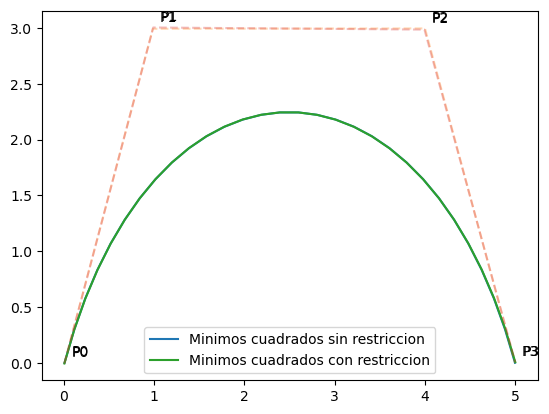

P1 restriccion: [[0.98972839 3.00128246]]
P1 sin restriccion: [0.98536458 2.98971294]
P2 restriccion: [[3.99639059 2.98228316]]
P2 sin restriccion: [4.00232683 2.99283736]


In [495]:
# Inciso (c)

t = []
for x in range(30):
    t.append(x / 29)

matriz_bernstein = bernstein3(t)
A_int = matriz_bernstein[:,1:3]
A_int.reshape(30,2)

# Inciso (d)

b0 = matriz_bernstein[:,0].reshape(30,1)
b3 = matriz_bernstein[:,3].reshape(30,1)

q1 = matriz_ruido[0].reshape(1,2)
qm = matriz_ruido[-1].reshape(1,2)

b0 = b0 @ q1
b3 = b3 @ qm

matriz_Q_mc = matriz_ruido - b0 - b3

P_sombrero = ec_normal(A_int, matriz_Q_mc)

P1_nuevo = P_sombrero[0].reshape(1,2)
P2_nuevo = P_sombrero[1].reshape(1,2)

print(P1_nuevo)
print(P2_nuevo)

P_restriccion = np.array([q1,P1_nuevo,P2_nuevo,qm]).reshape(4,2)

# Inciso (e)

nuevo_ajuste_restriccion = A @ P_restriccion

graficar_matriz(matriz_curva_ajustada, matriz_puntos_ajustados,"Minimos cuadrados sin restriccion")
graficar_matriz(nuevo_ajuste_restriccion, P_restriccion, "Minimos cuadrados con restriccion")
plt.legend()
plt.show()

print("P1 restriccion:", P1_nuevo)
print("P1 sin restriccion:", matriz_puntos_ajustados[1])

print("P2 restriccion:", P2_nuevo)
print("P2 sin restriccion:", matriz_puntos_ajustados[2])



El ajuste de minimos cuadrados con y sin restricción es el mismo. 

### Ejercicio 11

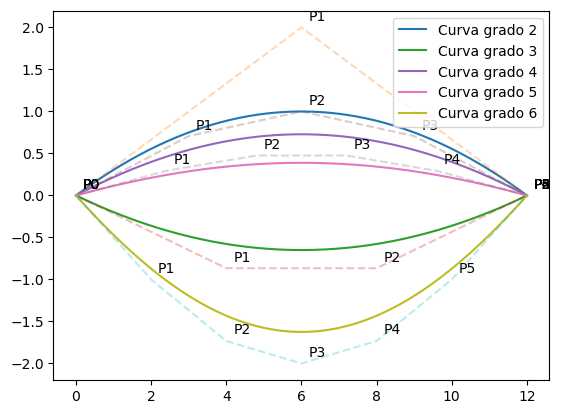

La curva de Bezier 1 tiene colisiones con obstaculos
--------------------------------
La curva de Bezier 2 tiene colisiones con obstaculos
--------------------------------
La curva de Bezier 3 tiene colisiones con obstaculos
--------------------------------
La curva de Bezier 4 tiene colisiones con obstaculos
--------------------------------
La curva de Bezier 5 tiene colisiones con obstaculos


In [496]:
# Inciso (a)

def bernstein_n(n,t):

    # Matriz de len(t) x (n+1)
    matriz_polinomios = []
    
    for t_i in t:
        fila = []
        for k in range(n+1):
            
            pol = (math.comb(n, k) * ((1-t_i)**(n-k)) * (t_i**k))
            fila.append(pol)
        matriz_polinomios.append(fila)
    
    matriz_polinomios = np.array(matriz_polinomios).reshape(len(t), n+1)
    return matriz_polinomios

# Inciso (b)

def bezier_n(P, t):
    matriz_A = bernstein_n(len(P)-1,t)
    return matriz_A @ P

# Inciso (c)


def verificar_colisiones(matriz_bezier):
    centros_obstaculos = [[2,1],[3,-2], [5,0], [7,2], [8,-2], [6,-2], [10,1], [11, -2]]
    radios_obstaculos = [1, 1, 1.5, 1, 1, 0.5, 1.5, 1]
    resultados = []

    for j in range(8):
        distancias = []
        for punto in matriz_bezier:
            
            distancias.append(math.sqrt((punto[0]-centros_obstaculos[j][0])**2 + (punto[1]-centros_obstaculos[j][1])**2))
            dist_min = np.min(distancias)

            hay_colision = dist_min < radios_obstaculos[j]
            resultados.append((dist_min, hay_colision))

    return resultados

def hay_colision(resultados):
    
    for i in range(len(resultados)):
        if(resultados[i][1] == True): 
            return True
    return False

# Inciso (d)


t = []

for i in range(200):
    x = i / 199
    t.append(x)

# Inciso (e)


def puntos_perturbados(n,a):
    puntos_control = []

    for k in range(n+1):
        punto = [12*k/n, a*math.sin(math.pi*k/n)]
        puntos_control.append(punto)
    puntos_control = np.array(puntos_control).reshape(n+1, 2)
    return puntos_control

grados = [2,3,4,5,6]

puntos_control_1 = puntos_perturbados(grados[0],2)
curva_bezier_1 = bezier_n(puntos_control_1, t)

puntos_control_2 = puntos_perturbados(grados[1],-1)
curva_bezier_2 = bezier_n(puntos_control_2, t)

puntos_control_3 = puntos_perturbados(grados[2],1)
curva_bezier_3 = bezier_n(puntos_control_3, t)

puntos_control_4 = puntos_perturbados(grados[3],0.5)
curva_bezier_4 = bezier_n(puntos_control_4, t)

puntos_control_5 = puntos_perturbados(grados[4],-2)
curva_bezier_5 = bezier_n(puntos_control_5, t)

# Inciso (f)

graficar_matriz(curva_bezier_1, puntos_control_1, "Curva grado 2")
graficar_matriz(curva_bezier_2, puntos_control_2, "Curva grado 3")
graficar_matriz(curva_bezier_3, puntos_control_3, "Curva grado 4")
graficar_matriz(curva_bezier_4, puntos_control_4, "Curva grado 5")
graficar_matriz(curva_bezier_5, puntos_control_5, "Curva grado 6")

plt.legend()
plt.show()

if(hay_colision(verificar_colisiones(curva_bezier_1))):
    print("La curva de Bezier 1 tiene colisiones con obstaculos")
else:
    print("La curva de Bezier 1 no tiene colisiones con obstaculos")


print("--------------------------------")
if(hay_colision(verificar_colisiones(curva_bezier_2))):
    print("La curva de Bezier 2 tiene colisiones con obstaculos")
else:
    print("La curva de Bezier 2 no tiene colisiones con obstaculos")

print("--------------------------------")
if(hay_colision(verificar_colisiones(curva_bezier_3))):
    print("La curva de Bezier 3 tiene colisiones con obstaculos")
else:
    print("La curva de Bezier 3 no tiene colisiones con obstaculos")

print("--------------------------------")
if(hay_colision(verificar_colisiones(curva_bezier_4))):
    print("La curva de Bezier 4 tiene colisiones con obstaculos")
else:
    print("La curva de Bezier 4 no tiene colisiones con obstaculos")


print("--------------------------------")
if(hay_colision(verificar_colisiones(curva_bezier_5))):
    print("La curva de Bezier 5 tiene colisiones con obstaculos")
else:
    print("La curva de Bezier 5 no tiene colisiones con obstaculos")


Inciso (g)

Una curva de Bézier de grado bajo tiene pocos puntos de control y, por lo tanto, poca capacidad para modificar su forma. Esto puede impedir que la trayectoria rodee adecuadamente los obstáculos del jardín, provocando colisiones. En cambio, al aumentar el grado se incorporan más puntos de control y la curva gana flexibilidad para adaptarse al entorno. Sin embargo, un grado excesivamente alto puede generar trayectorias innecesariamente complejas, con desvíos o cambios de dirección que no aportan ventajas significativas y aumentan la dificultad de optimización. Por este motivo, se busca encontrar el menor grado que permita obtener una trayectoria factible y segura.

### Ejercicio 12

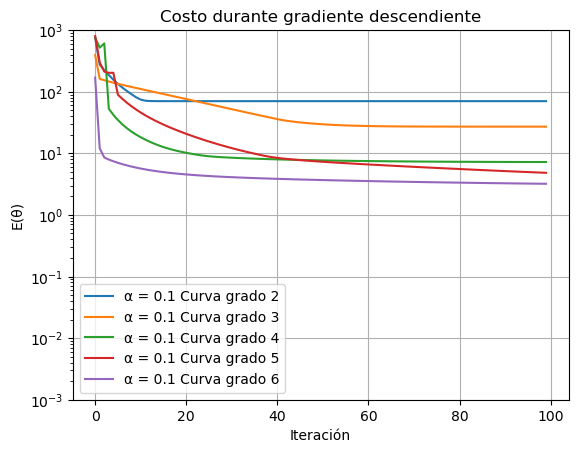

In [497]:
# Inciso (a)

def puntos_control_tita(tita):
    puntos_control = [[0, 0]]
    for i in range(0, len(tita)-1, 2):
        puntos_control.append([tita[i], tita[i+1]])
    puntos_control.append([12,0])

    puntos_control = np.array(puntos_control).reshape(len(puntos_control), 2)
    return puntos_control

def P_a_tita(P):
    return P[1:-1].reshape(-1)

# Inciso (b)

# 1) Este termino penaliza trayectorias largas

def costo_largo(curva):
    diferencias = curva[1:] - curva[:-1]
    largos_cuadrados = np.sum(diferencias**2, axis=1)
    return np.sum(largos_cuadrados)

# 2) Este termino penaliza cambios bruscos en los puntos de control
# Si los puntos están muy alineados o cambian suavemente, este valor es chico.

def costo_suavidad(P):
    total = 0

    for k in range(1, len(P) - 1):
        segunda_diferencia = P[k-1] - 2*P[k] + P[k+1]
        total += np.sum(segunda_diferencia**2)

    return total

# 3) Este término vale positivo si la trayectoria se acerca demasiado a un obstáculo. (no solo debe estar fuera de un obstaculo sino tambien cumplir con una distancia de seguridad).

centros_obstaculos = np.array([[2,1],[3,-2], [5,0], [7,2], [8,-2], [6,-2], [10,1], [11, -2]])
radios_obstaculos = np.array([1, 1, 1.5, 1, 1, 0.5, 1.5, 1])

def costo_obstaculos(curva, delta=0.3):
    total = 0

    for punto in curva:
        for centro, radio in zip(centros_obstaculos, radios_obstaculos):
            distancia = np.linalg.norm(punto - centro)
            penalizacion = max(0, radio + delta - distancia)
            total += penalizacion**2

    return total

# Calculamos costo total

def costo_total(tita, n, t, lambda_s=0.1, lambda_o=10, delta=0.3):
    P = puntos_control_tita(tita)
    curva = bezier_n(P, t)

    E_largo = costo_largo(curva)
    E_suavidad = costo_suavidad(P)
    E_obstaculos = costo_obstaculos(curva, delta)

    total = E_largo + lambda_s * E_suavidad + lambda_o * E_obstaculos

    return total


# Inciso (c)

def gradiente_diferencias_finitas(tita, n, t, lambda_s=0.1, lambda_o=10, delta=0.3, eps=1e-5):
    grad = np.zeros_like(tita)

    for k in range(len(tita)):
        e = np.zeros_like(tita)
        e[k] = 1

        costo_mas = costo_total(tita + eps*e, n, t, lambda_s, lambda_o, delta)
        costo_menos = costo_total(tita - eps*e, n, t, lambda_s, lambda_o, delta)

        grad[k] = (costo_mas - costo_menos) / (2*eps)

    return grad

# Gradiente descendiente para optimizacion trayectoria

def optimizar_trayectoria(P0, n, t, a=0.6, alpha=0.1, iteraciones=100, lambda_s=0.1, lambda_o=10, delta=0.3):

    tita = P_a_tita(P0)

    historial_costos = []

    for it in range(iteraciones):
        costo = costo_total(tita, n, t, lambda_s, lambda_o, delta)
        historial_costos.append(costo)

        grad = gradiente_diferencias_finitas(tita, n, t, lambda_s, lambda_o, delta)

        tita = tita - alpha * grad

    P_final = puntos_control_tita(tita)
    curva_final = bezier_n(P_final, t)

    return P_final, curva_final, historial_costos

puntos_control_opt1, curva_final_1, historial_costos_1 = optimizar_trayectoria(puntos_control_1, grados[0], t)
puntos_control_opt2, curva_final_2, historial_costos_2 = optimizar_trayectoria(puntos_control_2, grados[1], t)
puntos_control_opt3, curva_final_3, historial_costos_3 = optimizar_trayectoria(puntos_control_3, grados[2], t)
puntos_control_opt4, curva_final_4, historial_costos_4 = optimizar_trayectoria(puntos_control_4,grados[3], t)
puntos_control_opt5, curva_final_5, historial_costos_5 = optimizar_trayectoria(puntos_control_5,grados[4], t)

graficar_error(historial_costos_1, 0.1, "Curva grado 2")
graficar_error(historial_costos_2, 0.1, "Curva grado 3")
graficar_error(historial_costos_3, 0.1, "Curva grado 4")
graficar_error(historial_costos_4, 0.1, "Curva grado 5")
graficar_error(historial_costos_5, 0.1, "Curva grado 6")



plt.xlabel("Iteración")
plt.ylabel("E(θ)")
plt.yscale("log")
plt.ylim(1e-3, 1e3)
plt.title("Costo durante gradiente descendiente")
plt.grid(True)
plt.legend()

plt.show()



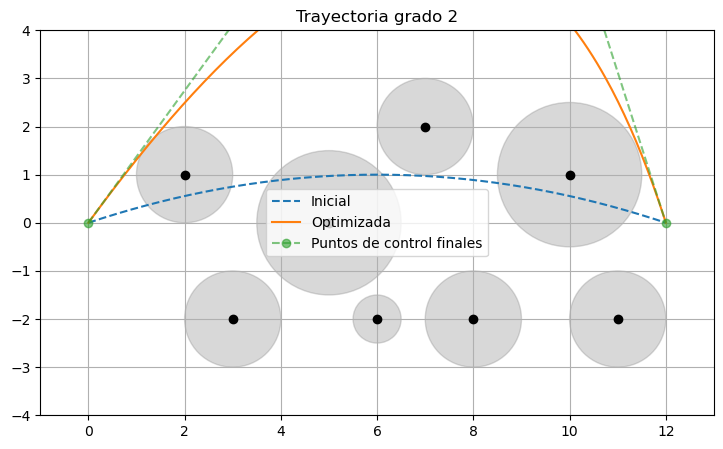

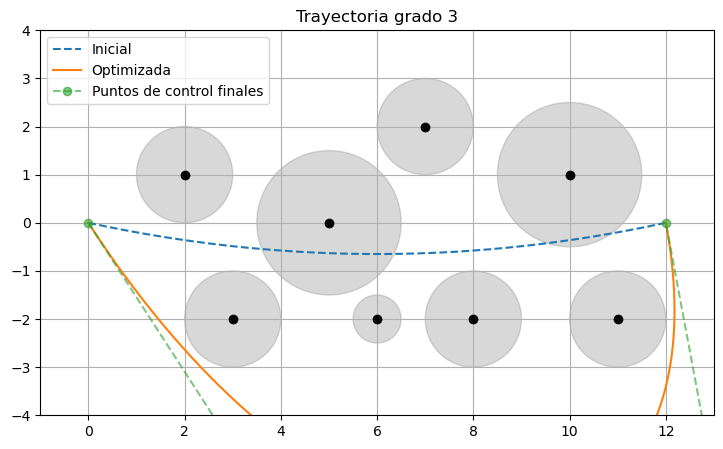

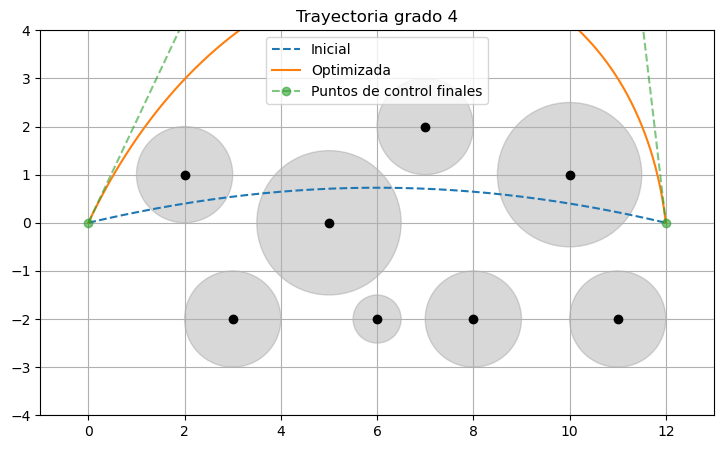

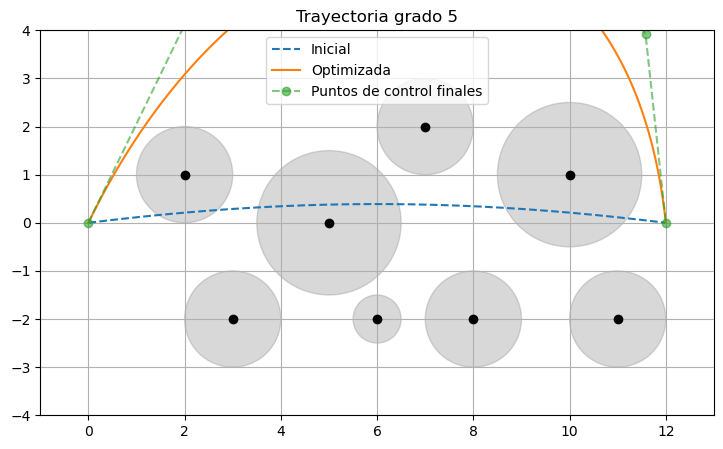

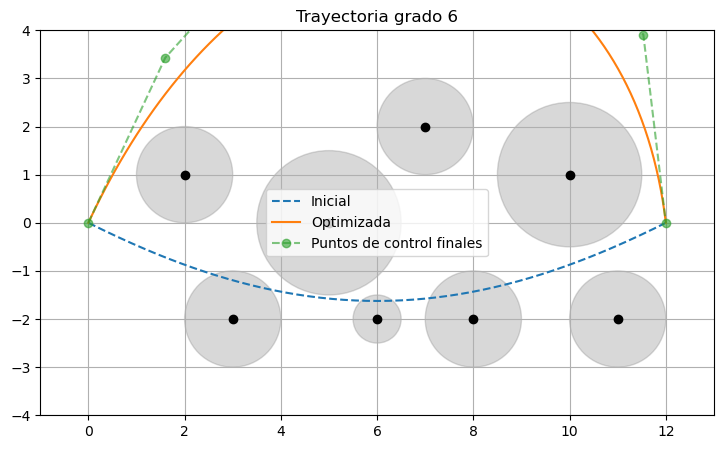

In [498]:
# Inciso (e)

def graficar_jardin():
    fig, ax = plt.subplots(figsize=(10, 5))

    for centro, radio in zip(centros_obstaculos, radios_obstaculos):
        circulo = plt.Circle(centro, radio, color="gray", alpha=0.3)
        ax.add_patch(circulo)
        ax.plot(centro[0], centro[1], "ko")

    ax.set_xlim(-1, 13)
    ax.set_ylim(-4, 4)
    ax.set_aspect("equal")
    ax.grid(True)

    return ax
puntos_iniciales = [
    puntos_control_1,
    puntos_control_2,
    puntos_control_3,
    puntos_control_4,
    puntos_control_5
]

puntos_optimizados = [
    puntos_control_opt1,
    puntos_control_opt2,
    puntos_control_opt3,
    puntos_control_opt4,
    puntos_control_opt5
]

curvas_finales = [
    curva_final_1,
    curva_final_2,
    curva_final_3,
    curva_final_4,
    curva_final_5
]

for grado, P_inicial, P_final, curva_final in zip(
    grados,
    puntos_iniciales,
    puntos_optimizados,
    curvas_finales
):
    curva_inicial = bezier_n(P_inicial, t)

    graficar_jardin()

    plt.plot(curva_inicial[:,0], curva_inicial[:,1], "--", label="Inicial")
    plt.plot(curva_final[:,0], curva_final[:,1], label="Optimizada")
    plt.plot(P_final[:,0], P_final[:,1], "o--", alpha=0.6, label="Puntos de control finales")

    plt.title(f"Trayectoria grado {grado}")
    plt.legend()
    plt.show()

In [499]:
# Inciso (f)

def analizar_factibilidad(curva, delta=0.3, y_min=-3, y_max=3):
    cantidad_colisiones = 0
    distancia_libre_minima_global = float("inf")

    for centro, radio in zip(centros_obstaculos, radios_obstaculos):
        distancias = np.linalg.norm(curva - centro, axis=1)

        distancia_minima_al_centro = np.min(distancias)
        distancia_libre = distancia_minima_al_centro - radio

        distancia_libre_minima_global = min(
            distancia_libre_minima_global,
            distancia_libre
        )

        if distancia_minima_al_centro < radio:
            cantidad_colisiones += 1

    se_sale_por_abajo = np.min(curva[:, 1]) < y_min
    se_sale_por_arriba = np.max(curva[:, 1]) > y_max
    dentro_del_jardin = not (se_sale_por_abajo or se_sale_por_arriba)

    es_factible = (
        cantidad_colisiones == 0
        and distancia_libre_minima_global >= delta
        and dentro_del_jardin
    )

    return (
        es_factible,
        cantidad_colisiones,
        distancia_libre_minima_global,
        dentro_del_jardin,
        np.min(curva[:, 1]),
        np.max(curva[:, 1])
    )


for grado, curva in zip(grados, curvas_finales):
    factible, colisiones, dist_libre, dentro, ymin, ymax = analizar_factibilidad(curva)

    print(
        f"Grado {grado}: "
        f"factible = {factible}, "
        f"colisiones = {colisiones}, "
        f"distancia libre mínima = {dist_libre:.4f}, "
        f"dentro del jardín = {dentro}, "
        f"y_min = {ymin:.4f}, "
        f"y_max = {ymax:.4f}"
    )

Grado 2: factible = False, colisiones = 1, distancia libre mínima = -0.0271, dentro del jardín = False, y_min = 0.0000, y_max = 5.7235
Grado 3: factible = False, colisiones = 0, distancia libre mínima = 0.1680, dentro del jardín = False, y_min = -6.2989, y_max = 0.0000
Grado 4: factible = False, colisiones = 0, distancia libre mínima = 0.2465, dentro del jardín = False, y_min = 0.0000, y_max = 5.3301
Grado 5: factible = False, colisiones = 0, distancia libre mínima = 0.2530, dentro del jardín = False, y_min = 0.0000, y_max = 5.9101
Grado 6: factible = False, colisiones = 0, distancia libre mínima = 0.2766, dentro del jardín = False, y_min = 0.0000, y_max = 5.8125


Al aumentar el grado, la trayectoria gana flexibilidad y logra alejarse progresivamente de los obstáculos. El grado 2 presenta colisión, mientras que los grados 3 a 6 evitan los obstáculos. Sin embargo, ninguna trayectoria alcanza la distancia de seguridad requerida de δ=0.3, por lo que ninguna resulta factible con los parámetros de optimización utilizados.

In [500]:
# Inciso (g)

menor_grado_factible = None

for grado, curva in zip(grados, curvas_finales):
    factible, colisiones, dist_libre, dentro, ymin, ymax = analizar_factibilidad(curva)

    if factible:
        menor_grado_factible = grado
        break

if menor_grado_factible is not None:
    print(f"El menor grado factible encontrado es n = {menor_grado_factible}.")
else:
    print("No se encontró una trayectoria factible para los grados probados.")

if menor_grado_factible is not None:
    print(
        f"Elegimos n = {menor_grado_factible} porque es el primer grado que cumple "
        "simultáneamente las condiciones de factibilidad: no colisiona con obstáculos, "
        "mantiene la distancia de seguridad delta y permanece dentro del jardín."
    )
else:
    print(
        "Con los parámetros utilizados, ningún grado entre 2 y 6 resultó factible. "
        "Esto sugiere que habría que ajustar la optimización, por ejemplo aumentando "
        "las iteraciones, modificando alpha o cambiando los pesos de la función de costo."
    )

No se encontró una trayectoria factible para los grados probados.
Con los parámetros utilizados, ningún grado entre 2 y 6 resultó factible. Esto sugiere que habría que ajustar la optimización, por ejemplo aumentando las iteraciones, modificando alpha o cambiando los pesos de la función de costo.
